Fig 4B

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import torch
import torch.nn.functional as F
from einops import rearrange
from einops import einsum as einops_einsum
from tqdm import tqdm

sys.path.insert(0, str(Path('../../..').resolve()))
from src.models import Transformer
from src.datasets.CopyFirstLastICLDataset import CopyFirstLastICLDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [2]:
RESULTS_ROOT = Path('../../../results/icl_copy_firstlast/runs')
SAVE_DIR     = Path('../../../figures/icl_refusaltraining')

CF_COLOR  = '#e74c3c'
CL_COLOR  = '#3498db'
BATCH_SZ  = 64
N_EVAL    = 500
MIN_ACC   = 0.90
REFUSAL_TYPES = ['copy_first', 'copy_last']

# ── Interleaved seed split (unchanged from the original analysis) ──────────
_INTER_DIR  = RESULTS_ROOT / '20260410170109_startCopyFirstFrac0.5_endCopyFirstFrac0.5_n30seeds'
_GEN_SEEDS  = {'seed_56', 'seed_58', 'seed_62', 'seed_63',
               'seed_66', 'seed_68', 'seed_69', 'seed_70'}
_ALL_INTER  = {f'seed_{i}' for i in range(50, 80)}
_MEM_SEEDS  = _ALL_INTER - _GEN_SEEDS

# ── Panel definitions — EDIT HERE ──────────────────────────────────────────
# Two panels, left → right.
PANEL_CONFIGS = [
    {
        'name':        'Curriculum - Copy Last',
        'panel_title': 'Imbalanced',
        'group_dir':   RESULTS_ROOT / '20260410170109_startCopyFirstFrac0.1_endCopyFirstFrac0.5_n30seeds',
        'seeds':       None,     # None → quality filter (MIN_ACC)
    },
    {
        'name':        'Interleaved - Generalizing',
        'panel_title': 'Balanced',
        'group_dir':   _INTER_DIR,
        'seeds':       _GEN_SEEDS,
    },
]

# Quick-test override: replace with a small explicit set, e.g.:
# PANEL_CONFIGS[0]['seeds'] = ['seed_50', 'seed_51']
# PANEL_CONFIGS[1]['seeds'] = {'seed_56', 'seed_58'}


In [3]:
def format_axis(ax, line_width_multiplier=2, font_size_multiplier=1):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()
    ax.get_yaxis().tick_left()
    ax.xaxis.set_tick_params(size=8 * font_size_multiplier)
    ax.yaxis.set_tick_params(size=8 * font_size_multiplier)
    for axis in ['top', 'bottom', 'left', 'right']:
        ax.spines[axis].set_linewidth(2 * line_width_multiplier)
    ax.tick_params(width=2 * line_width_multiplier)
    ax.xaxis.label.set_fontsize(16 * font_size_multiplier)
    ax.yaxis.label.set_fontsize(16 * font_size_multiplier)
    for item in ax.get_xticklabels() + ax.get_yticklabels():
        item.set_fontsize(14 * font_size_multiplier)
    for line in ax.lines:
        line.set_linewidth(2.5 * font_size_multiplier)
    ax.title.set_fontsize(24 * font_size_multiplier)


def load_seed_dirs(group_dir, allowed_seeds=None, min_acc=MIN_ACC):
    seed_dirs = []
    for seed_dir in sorted(group_dir.iterdir()):
        if not seed_dir.is_dir() or not seed_dir.name.startswith('seed_'):
            continue
        if allowed_seeds is not None:
            if seed_dir.name not in allowed_seeds:
                continue
        else:
            rf = seed_dir / 'results.json'
            if not rf.exists():
                continue
            with open(rf) as f:
                data = json.load(f)
            pt = data['pretraining']
            if (max(pt['copy_first_accuracy']) < min_acc
                    or max(pt['copy_last_accuracy']) < min_acc):
                continue
        has_both = all(
            (seed_dir / f'pure_refusal_{rt}_kept0.10' / 'finetuned_checkpoint.pt').exists()
            for rt in REFUSAL_TYPES
        )
        if has_both:
            seed_dirs.append(seed_dir)
    return seed_dirs


def load_refusal_model(seed_dir, refusal_type):
    ref_dir = seed_dir / f'pure_refusal_{refusal_type}_kept0.10'
    ckpt = torch.load(ref_dir / 'finetuned_checkpoint.pt',
                      map_location=device, weights_only=False)
    model_config = ckpt['model_config']
    state_dict = {k.replace('_orig_mod.', ''): v
                  for k, v in ckpt['model_state_dict'].items()}
    model = Transformer(**model_config)
    model.load_state_dict(state_dict)
    model = model.to(device).eval()
    with open(ref_dir / 'results.json') as f:
        config = json.load(f)['config']
    return model, config


def make_eval_dataset(config, seed_offset=1000):
    return CopyFirstLastICLDataset(
        n_sequences=N_EVAL,
        symbol_vocab_size=config['symbol_vocab_size'],
        feature_len=config['feature_len'],
        n_context_examples=config['n_context_examples'],
        task_distribution={'copy_first': 0.5, 'copy_last': 0.5},
        mode='standard',
        seed=config['pretrain_seed'] + seed_offset,
    )

In [4]:

def create_corrupted_inputs(sequences, tasks, feature_len, n_context_examples):
    """Flip context labels: copy_first ↔ copy_last features."""
    corrupted  = sequences.clone()
    block_size = feature_len + 3
    for i in range(n_context_examples):
        feat_start     = i * block_size
        label_pos      = feat_start + feature_len + 1
        first_feat_pos = feat_start
        last_feat_pos  = feat_start + feature_len - 1
        for seq_idx in range(len(sequences)):
            if tasks[seq_idx] == 'copy_first':
                corrupted[seq_idx, label_pos] = sequences[seq_idx, last_feat_pos]
            else:
                corrupted[seq_idx, label_pos] = sequences[seq_idx, first_feat_pos]
    return corrupted


@torch.no_grad()
def run_act_patching_b1_detail(model, eval_dataset, refuse_task, batch_size=BATCH_SZ):
    """
    Matched activation patching at Block 1 (L2).
    Clean = refused-task sequences; corrupt = same features, labels flipped.
    Patches Q / K / V / FFN one at a time; reports refusal fraction on corrupt seqs.
    """
    refuse_token = eval_dataset.refuse_token
    b1 = model.blocks[1]

    clean_idx   = (eval_dataset.get_copy_first_indices()
                   if refuse_task == 'copy_first'
                   else eval_dataset.get_copy_last_indices())
    clean_seqs  = eval_dataset.sequences[clean_idx]
    tasks_clean = [eval_dataset.tasks[i] for i in clean_idx.tolist()]

    corrupt_seqs = create_corrupted_inputs(
        clean_seqs, tasks_clean,
        eval_dataset.feature_len, eval_dataset.n_context_examples,
    )

    n_seqs      = len(clean_seqs)
    clean_ids   = clean_seqs.to(device)
    corrupt_ids = corrupt_seqs.to(device)

    # ── Cache per-sequence L2 Q / K / V / FFN for the clean sequences ──────
    qs, ks, vs, ffns = [], [], [], []
    for s in range(0, n_seqs, batch_size):
        ids     = clean_ids[s:s + batch_size]
        seq_len = ids.shape[1]
        tok_emb = model.token_emb(ids)
        x = (tok_emb + model.pos_enc(torch.arange(seq_len, device=ids.device))
             if model.use_learned_pe else model.pos_enc(tok_emb))
        x = model.dropout(x)
        x = model.blocks[0](x)
        qkv    = b1.attn.qkv(b1.ln1(x))
        q, k, v = rearrange(qkv, 'b n (three h d) -> three b h n d',
                             three=3, h=b1.attn.n_heads)
        sc  = einops_einsum(q, k, 'b h i d, b h j d -> b h i j') * b1.attn.scale
        msk = torch.triu(torch.ones(seq_len, seq_len, device=ids.device, dtype=torch.bool),
                         diagonal=1)
        w   = F.softmax(sc.masked_fill(msk, float('-inf')), dim=-1)
        o   = rearrange(einops_einsum(w, v, 'b h i j, b h j d -> b h i d'), 'b h n d -> b n (h d)')
        x_post = x + b1.attn.out_proj(o)
        qs.append(q.cpu()); ks.append(k.cpu()); vs.append(v.cpu())
        ffns.append(b1.ff(b1.ln2(x_post)).cpu())

    clean_q   = torch.cat(qs)
    clean_k   = torch.cat(ks)
    clean_v   = torch.cat(vs)
    clean_ffn = torch.cat(ffns)

    # ── Patch one component at a time into corrupt sequences ────────────────
    def _patch_and_measure(which):
        preds = []
        for s in range(0, n_seqs, batch_size):
            e       = min(s + batch_size, n_seqs)
            ids     = corrupt_ids[s:e]
            seq_len = ids.shape[1]
            tok_emb = model.token_emb(ids)
            x = (tok_emb + model.pos_enc(torch.arange(seq_len, device=ids.device))
                 if model.use_learned_pe else model.pos_enc(tok_emb))
            x = model.dropout(x)
            x = model.blocks[0](x)
            qkv    = b1.attn.qkv(b1.ln1(x))
            q, k, v = rearrange(qkv, 'b n (three h d) -> three b h n d',
                                 three=3, h=b1.attn.n_heads)
            if which == 'q': q = clean_q[s:e].to(device)
            elif which == 'k': k = clean_k[s:e].to(device)
            elif which == 'v': v = clean_v[s:e].to(device)
            sc  = einops_einsum(q, k, 'b h i d, b h j d -> b h i j') * b1.attn.scale
            msk = torch.triu(torch.ones(seq_len, seq_len, device=ids.device, dtype=torch.bool),
                             diagonal=1)
            w   = F.softmax(sc.masked_fill(msk, float('-inf')), dim=-1)
            o   = rearrange(einops_einsum(w, v, 'b h i j, b h j d -> b h i d'), 'b h n d -> b n (h d)')
            x_post = x + b1.attn.out_proj(o)
            if which == 'ffn':
                x_out = x_post + clean_ffn[s:e].to(device)
            elif not getattr(b1, 'attention_only', False):
                x_out = x_post + b1.ff(b1.ln2(x_post))
            else:
                x_out = x_post
            preds.append(model.lm_head(model.ln_f(x_out))[:, -1, :].argmax(-1).cpu())
        return (torch.cat(preds) == refuse_token).float().mean().item()

    cross_fracs = np.array([_patch_and_measure(w) for w in ['q', 'k', 'v', 'ffn']])
    labels      = ['L2 Q', 'L2 K', 'L2 V', 'L2 FFN']
    nan_arr     = np.full(len(labels), np.nan)

    if refuse_task == 'copy_first':
        return {'labels': labels, 'cf_ref_frac': nan_arr, 'cl_ref_frac': cross_fracs}
    else:
        return {'labels': labels, 'cf_ref_frac': cross_fracs, 'cl_ref_frac': nan_arr}

In [5]:
panel_results = {}  # cat_name → {'copy_first': [...], 'copy_last': [...]}

for cfg in PANEL_CONFIGS:
    cat_name  = cfg['name']
    seed_dirs = load_seed_dirs(cfg['group_dir'], cfg['seeds'])
    print(f"{cat_name}: {len(seed_dirs)} seeds")

    cat_data = {rt: [] for rt in REFUSAL_TYPES}
    for seed_dir in tqdm(seed_dirs, desc=cat_name):
        for refusal_type in REFUSAL_TYPES:
            model, config = load_refusal_model(seed_dir, refusal_type)
            eval_ds       = make_eval_dataset(config)
            cat_data[refusal_type].append(
                run_act_patching_b1_detail(model, eval_ds, refusal_type)
            )
            del model
            if device.type == 'cuda':
                torch.cuda.empty_cache()

    panel_results[cat_name] = cat_data

print("Done.")

Curriculum - Copy Last: 30 seeds


Curriculum - Copy Last: 100%|██████████| 30/30 [00:13<00:00,  2.20it/s]


Interleaved - Generalizing: 8 seeds


Interleaved - Generalizing: 100%|██████████| 8/8 [00:04<00:00,  1.98it/s]

Done.


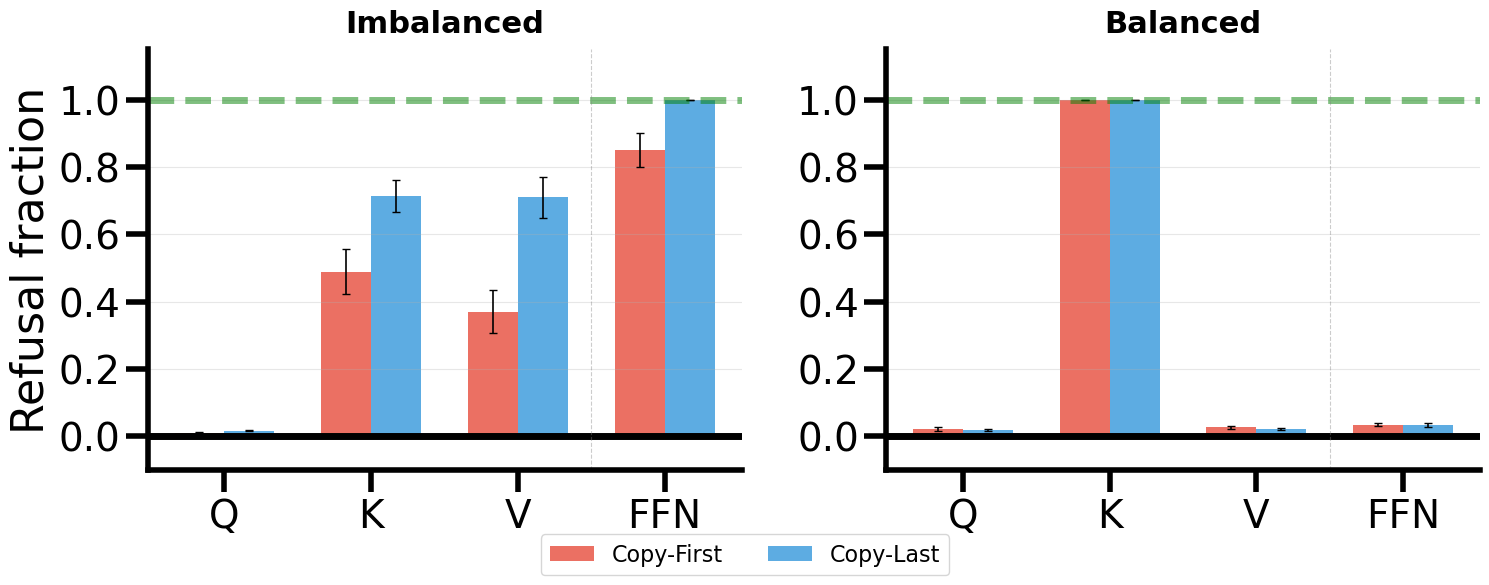

In [6]:
def _sem(arr_2d):
    n = arr_2d.shape[0]
    return arr_2d.std(0) / np.sqrt(n) if n > 1 else np.zeros(arr_2d.shape[1])


fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))

for ax_i, cfg in enumerate(PANEL_CONFIGS):
    ax          = axes[ax_i]
    cat_name    = cfg['name']
    panel_title = cfg['panel_title']

    cl_seeds = panel_results[cat_name]['copy_last']   # refuse CL → red bars
    cf_seeds = panel_results[cat_name]['copy_first']  # refuse CF → blue bars

    labels = (cl_seeds or cf_seeds)[0]['labels']
    x      = np.arange(len(labels))
    width  = 0.34

    red_arr  = (np.array([s['cf_ref_frac'] for s in cl_seeds])
                if cl_seeds else np.zeros((1, len(labels))))
    blue_arr = (np.array([s['cl_ref_frac'] for s in cf_seeds])
                if cf_seeds else np.zeros((1, len(labels))))

    ax.bar(x - width / 2, red_arr.mean(0),  width, yerr=_sem(red_arr),  capsize=3,
           color=CF_COLOR, alpha=0.8, error_kw={'linewidth': 1.2}, label='Copy-First')
    ax.bar(x + width / 2, blue_arr.mean(0), width, yerr=_sem(blue_arr), capsize=3,
           color=CL_COLOR, alpha=0.8, error_kw={'linewidth': 1.2}, label='Copy-Last')

    ax.axhline(0, color='black', linewidth=0.8)
    ax.axhline(1, color='green', linewidth=1.0, linestyle='--', alpha=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels([lbl.replace('L2 ', '') for lbl in labels])
    if ax_i == 0:
        ax.set_ylabel('Refusal fraction')
    ax.set_ylim(-0.1, 1.15)
    ax.grid(axis='y', alpha=0.3)
    format_axis(ax, line_width_multiplier=2.0, font_size_multiplier=2)
    ax.set_title(panel_title, fontsize=22, fontweight='bold', pad=12)

    if 'L2 FFN' in labels:
        sep_x = list(labels).index('L2 FFN') - 0.5
        ax.axvline(sep_x, color='gray', linewidth=0.8, linestyle='--', alpha=0.4)

fig.legend(
    handles=[
        Patch(facecolor=CF_COLOR, alpha=0.8, label='Copy-First'),
        Patch(facecolor=CL_COLOR, alpha=0.8, label='Copy-Last'),
    ],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    fontsize=16,
)

plt.tight_layout(w_pad=4)
fig.subplots_adjust(bottom=0.18)
plt.show()